# System Dynamics Behavioural Assessment

This notebook examines the behaviour of the system dynamics (SD) component under changes to its principal inputs and policy functions. It also illustrates the conversion of SD referral flows into interval-based arrival rates for the discrete-event simulation (DES).

The notebook is organised as follows:

1. configuration and reusable helper functions;
2. conversion of SD referral flows to Ciw arrivals;
3. gatekeeping and presenting behaviour;
4. deterioration, population split, incidence, and recovery behaviour; and
5. the combined effects of deterioration and strict-priority gatekeeping.

Unless stated otherwise, severity is stored in the order **Low, Medium, High**.

## Setup

In [2]:
from pathlib import Path
import sys

import ciw
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import numpy as np

# Repository imports
root_dir = Path("../../..").resolve()
src_dir = root_dir / "src"
if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

from hybridsim import sd_component as sd
from hybridsim import gatekeeping_functions as gk

### Configuration

In [3]:
# Simulation horizon
HORIZON_DAYS = 365 * 3

# The original notebook used different time grids for different purposes.
# They are named explicitly here to avoid silently overwriting `ts`.
FINE_TIME_POINTS = np.linspace(0, HORIZON_DAYS, 100_000 + 1)
PLOT_TIME_POINTS = np.linspace(0, HORIZON_DAYS, 100 + 1)
DAILY_TIME_POINTS = np.arange(0, HORIZON_DAYS + 1, dtype=float)

# Baseline SD parameters
POPULATION_SIZE = 100_000
INITIAL_UNWELL_PROPORTION = 0.10
BASE_UNWELL_SPLITS = (0.60, 0.30, 0.10)  # Low, Medium, High
BASE_PRESENTING_PROPORTION = 0.002
BASE_INCIDENCE_RATE = 0.0
BASE_RECOVERY_RATE = 0.0

# Severity display settings
SEVERITY_LABELS = ("Low", "Medium", "High")
SEVERITY_COLOURS = {
    "Low": "#D81B60",
    "Medium": "#1E88E5",
    "High": "#FFC107",
}

# Output location
PLOT_DIR = Path("../plots").resolve()
PLOT_DIR.mkdir(parents=True, exist_ok=True)

### Reusable model and plotting functions

In [4]:
def zero_deterioration_rate_function(t):
    """
    Returns the deterioration rate as a function of time.
    """
    return 0.00


def run_sd_model(
    *,
    time_points,
    gatekeeping_function,
    unwell_splits=BASE_UNWELL_SPLITS,
    presenting_proportion=BASE_PRESENTING_PROPORTION,
    deterioration_function=zero_deterioration_rate_function,
    incidence_rate=BASE_INCIDENCE_RATE,
    recovery_rate=BASE_RECOVERY_RATE,
):
    """Construct, solve, and extract results from one SD model scenario."""
    model = sd.SD(
        population_function=sd.get_time_dependent_population_size(
            POPULATION_SIZE,
            HORIZON_DAYS,
        ),
        initial_unwell_proportion=INITIAL_UNWELL_PROPORTION,
        unwell_splits=list(unwell_splits),
        gatekeeping_function=gatekeeping_function,
        presenting_proportion=presenting_proportion,
        deterioration_function=deterioration_function,
        incidence_function=sd.get_time_dependent_incidence_rate(
            [incidence_rate],
            HORIZON_DAYS,
        ),
        recovery_function=sd.get_time_dependent_recovery_rate(
            [recovery_rate],
            HORIZON_DAYS,
        ),
    )

    model.solve(t=time_points)

    return {
        "model": model,
        "stocks": np.asarray(model.P).copy(),
        "referrals": np.asarray(model.lambdas).copy(),
    }

In [5]:
def _format_axis(ax):
    """Apply common axis formatting."""
    ax.grid(
        True,
        which="both",
        linestyle="--",
        linewidth=0.5,
        color="gray",
    )


def plot_stocks_over_time_ax(
    ax,
    stocks,
    time_points,
    *,
    ylim=None,
    title=None,
    show_legend=False,
    legend_fontsize=10,
):
    """Plot Low, Medium, and High SD stocks on one axis."""
    for stock, severity in zip(stocks, SEVERITY_LABELS):
        ax.plot(
            time_points,
            stock,
            label=rf"$P_{{\mathrm{{{severity.lower()}}}}}$",
            color=SEVERITY_COLOURS[severity],
        )

    if title:
        ax.set_title(title, fontsize=12)

    if ylim is not None:
        ax.set_ylim(ylim)

    if show_legend:
        ax.legend(fontsize=legend_fontsize, loc="upper right")

    _format_axis(ax)


def plot_referral_rates_ax(
    ax,
    referral_rates,
    time_points,
    *,
    ylim=None,
    title=None,
    show_legend=False,
    legend_fontsize=10,
):
    """Plot Low, Medium, and High SD referral flows on one axis."""
    for referral_rate, severity in zip(referral_rates, SEVERITY_LABELS):
        ax.plot(
            time_points,
            referral_rate,
            label=rf"$\Lambda_{{\mathrm{{{severity.lower()}}}}}$",
            color=SEVERITY_COLOURS[severity],
        )

    if title:
        ax.set_title(title, fontsize=12)

    if ylim is not None:
        ax.set_ylim(ylim)

    if show_legend:
        ax.legend(fontsize=legend_fontsize, loc="upper right")

    _format_axis(ax)


def plot_stacked_stocks_over_time_ax(
    ax,
    stocks,
    time_points,
    *,
    threshold=None,
    title=None,
    show_legend=False,
    legend_fontsize=10,
):
    """
    Plot stacked SD stocks.

    Stocks are supplied in model order (Low, Medium, High), but are
    displayed with High at the bottom, Medium in the middle, and Low
    at the top.
    """
    p_low, p_medium, p_high = stocks

    high_upper = p_high
    medium_upper = p_high + p_medium
    low_upper = p_high + p_medium + p_low

    ax.fill_between(
        time_points,
        0,
        high_upper,
        color=SEVERITY_COLOURS["High"],
        label=r"$P_{\mathrm{high}}$",
    )
    ax.fill_between(
        time_points,
        high_upper,
        medium_upper,
        color=SEVERITY_COLOURS["Medium"],
        label=r"$P_{\mathrm{medium}}$",
    )
    ax.fill_between(
        time_points,
        medium_upper,
        low_upper,
        color=SEVERITY_COLOURS["Low"],
        label=r"$P_{\mathrm{low}}$",
    )

    if threshold is not None:
        ax.plot(
            time_points,
            low_upper * threshold,
            color="black",
            linestyle="--",
            label="Threshold",
        )

    if title:
        ax.set_title(title, fontsize=12)

    if show_legend:
        ax.legend(fontsize=legend_fontsize, loc="upper right")

    _format_axis(ax)

In [6]:
def plot_three_row_comparison(
    results,
    column_titles,
    time_points,
    *,
    stock_ylim=(0, 10_000),
    referral_ylim=None,
    output_filename=None,
):
    """Plot stocks, stacked stocks, and referral flows for several scenarios."""
    fig, axes = plt.subplots(
        3,
        len(results),
        figsize=(4 * len(results), 10),
        sharex=True,
        squeeze=False,
    )

    for column_index, (result, title) in enumerate(
        zip(results, column_titles)
    ):
        show_legend = column_index == len(results) - 1

        plot_stocks_over_time_ax(
            axes[0, column_index],
            result["stocks"],
            time_points,
            ylim=stock_ylim,
            title=title,
            show_legend=show_legend,
        )
        plot_stacked_stocks_over_time_ax(
            axes[1, column_index],
            result["stocks"],
            time_points,
            show_legend=show_legend,
        )
        plot_referral_rates_ax(
            axes[2, column_index],
            result["referrals"],
            time_points,
            ylim=referral_ylim,
            show_legend=show_legend,
        )

        axes[2, column_index].set_xlabel("Time (days)", fontsize=12)

    axes[0, 0].set_ylabel("Stock size", fontsize=12)
    axes[1, 0].set_ylabel("Total stock size (stacked)", fontsize=12)
    axes[2, 0].set_ylabel("Referral rate\n(patients per day)", fontsize=12)

    fig.tight_layout()

    if output_filename:
        fig.savefig(
            PLOT_DIR / output_filename,
            dpi=300,
            bbox_inches="tight",
        )

    plt.show()


def plot_stacked_scenario_grid(
    results,
    titles,
    time_points,
    *,
    output_filename=None,
    ncols=3,
):
    """Plot a collection of stacked-stock scenarios on a regular grid."""
    nrows = int(np.ceil(len(results) / ncols))

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(6 * ncols, 5 * nrows),
        sharex=False,
        sharey=True,
        squeeze=False,
    )
    axes = axes.ravel()

    for index, (result, title) in enumerate(zip(results, titles)):
        plot_stacked_stocks_over_time_ax(
            axes[index],
            result["stocks"],
            time_points,
            title=title,
            show_legend=index == len(results) - 1,
        )

        if index % ncols == 0:
            axes[index].set_ylabel(
                "Total stock size (stacked)",
                fontsize=12,
            )

        if index >= (nrows - 1) * ncols:
            axes[index].set_xlabel("Time (days)", fontsize=12)

    for ax in axes[len(results):]:
        ax.set_visible(False)

    fig.tight_layout()
    fig.subplots_adjust(hspace=0.22)

    if output_filename:
        fig.savefig(
            PLOT_DIR / output_filename,
            dpi=300,
            bbox_inches="tight",
        )

    plt.show()

## Conversion to Ciw Arrivals

This section uses daily evaluation points so that each Ciw interval corresponds explicitly to one simulation day. Only one SD scenario is required for the conversion illustration; the threshold sweep is examined separately below.

In [7]:
conversion_result = run_sd_model(
    time_points=DAILY_TIME_POINTS,
    gatekeeping_function=gk.strict_priority_gatekeeping(
        threshold=1.0,
    ),
    presenting_proportion=BASE_PRESENTING_PROPORTION,
    deterioration_function=zero_deterioration_rate_function,
)

# Ciw expects one rate for each interval ending at the supplied endpoint.
# Transpose from (severity, time) to (time, severity).
lambdas = conversion_result["referrals"].T
des_rates = lambdas[:-1, :]

gp_arrivals = [
    ciw.dists.PoissonIntervals(
        rates=list(des_rates[:, severity_index]),
        endpoints=list(DAILY_TIME_POINTS[1:]),
        max_sample_date=HORIZON_DAYS,
    )
    for severity_index in range(len(SEVERITY_LABELS))
]

for interval_index in range(5):
    print(
        f"{DAILY_TIME_POINTS[interval_index]:.0f} to "
        f"{DAILY_TIME_POINTS[interval_index + 1]:.0f} days: "
        f"Low rate = {des_rates[interval_index, 0]:.6f}"
    )

0 to 1 days: Low rate = 12.000000
1 to 2 days: Low rate = 11.976024
2 to 3 days: Low rate = 11.952096
3 to 4 days: Low rate = 11.928216
4 to 5 days: Low rate = 11.904383


In [8]:
ts = np.linspace(0, 365 * 3, 100000 + 1)
incidence_props = [0.0]
recovery = 0.0

In [9]:
def deterioration_rate_function(t):
    """
    Returns the deterioration rate as a function of time.
    """
    return 0.00

In [ ]:
thresholds = [0.0, 1 / 3, 2 / 3, 1.0]

p_low_results = []
p_medium_results = []
p_high_results = []

lambda_low_results = []
lambda_medium_results = []
lambda_high_results = []

ts = np.linspace(0, 365 * 3, 100 + 1)

for threshold in thresholds:
    A = sd.SD(
        population_function=sd.get_time_dependent_population_size(
            100000,
            365 * 3,
        ),
        initial_unwell_proportion=0.1,
        unwell_splits=[0.6, 0.3, 0.1],  # Low, Medium, High
        gatekeeping_function=gk.strict_priority_gatekeeping(
            threshold=threshold,
        ),
        presenting_proportion=0.002,
        deterioration_function=deterioration_rate_function,
        incidence_function=sd.get_time_dependent_incidence_rate(
            [incidence_props[-1]],
            365 * 3,
        ),
        recovery_function=sd.get_time_dependent_recovery_rate(
            [recovery],
            365 * 3,
        ),
    )

    A.solve(t=ts)

    # SD storage order is Low, Medium, High.
    p_low_results.append(np.copy(A.P[0]))
    p_medium_results.append(np.copy(A.P[1]))
    p_high_results.append(np.copy(A.P[2]))

    lambda_low_results.append(np.copy(A.lambdas[0]))
    lambda_medium_results.append(np.copy(A.lambdas[1]))
    lambda_high_results.append(np.copy(A.lambdas[2]))

In [184]:
thresholds = [0.0, 1 / 3, 2 / 3, 1.0, 0.1]

p_low_results = []
p_medium_results = []
p_high_results = []

lambda_low_results = []
lambda_medium_results = []
lambda_high_results = []

ts = np.linspace(0, 365 * 3, 100 + 1)

for threshold in thresholds:
    A = sd.SD(
        population_function=sd.get_time_dependent_population_size(
            100000,
            365 * 3,
        ),
        initial_unwell_proportion=0.1,
        unwell_splits=[0.6, 0.3, 0.1],  # Low, Medium, High
        gatekeeping_function=gk.weighted_priority_gatekeeping(
            threshold=threshold,
            weights=[1.0, 1.0, 1.0]
        ),
        presenting_proportion=0.002,
        deterioration_function=deterioration_rate_function,
        incidence_function=sd.get_time_dependent_incidence_rate(
            [incidence_props[-1]],
            365 * 3,
        ),
        recovery_function=sd.get_time_dependent_recovery_rate(
            [recovery],
            365 * 3,
        ),
    )

    A.solve(t=ts)

    # SD storage order is Low, Medium, High.
    p_low_results.append(np.copy(A.P[0]))
    p_medium_results.append(np.copy(A.P[1]))
    p_high_results.append(np.copy(A.P[2]))

    lambda_low_results.append(np.copy(A.lambdas[0]))
    lambda_medium_results.append(np.copy(A.lambdas[1]))
    lambda_high_results.append(np.copy(A.lambdas[2]))

In [185]:
lambdas = A.lambdas.T

In [187]:
lambdas_warm_up, ts_warmup = sd.add_constant_lambda_warmup(lambdas.T, ts, warmup_days=90, value="initial")

In [190]:
gp_arrivals = [
        ciw.dists.PoissonIntervals(
            rates=list(lambdas[:-1, severity_index]),
            endpoints=list(ts[1:]),
            max_sample_date=365 * 3,
        )
        for severity_index in range(3)
    ]

In [191]:
gp_arrivals_warmup = [
        ciw.dists.PoissonIntervals(
            rates=list(lambdas_warm_up.T[:-1, severity_index]),
            endpoints=list(ts_warmup[1:]),
            max_sample_date=365 * 3 + 5,
        )
        for severity_index in range(3)
    ]

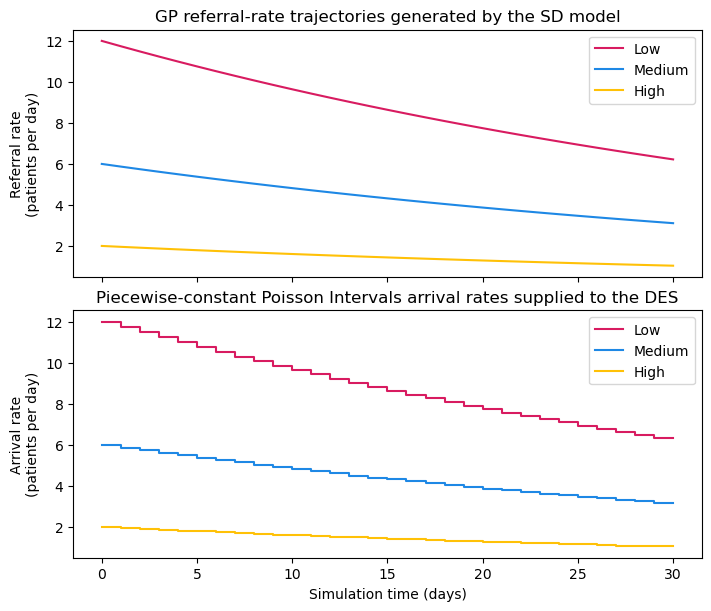

In [17]:
des_rates = lambdas[:-1, :]

severity_labels = ["Low", "Medium", "High"]

days_to_plot = 30
n_days = min(days_to_plot, des_rates.shape[0])

time_points = np.arange(n_days + 1)

fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(7, 6),
    sharex=True,
    constrained_layout=True,
)

colors = ["#D81B60", "#1E88E5", "#FFC107"]  # High, Medium, Low

for severity_index, (severity_label, colour) in enumerate(
    zip(severity_labels, colors)
):

    axes[0].plot(
        time_points,
        lambdas[:n_days + 1, severity_index],
        label=severity_label,
        color=colour,
    )

    step_values = np.append(
        des_rates[:n_days, severity_index],
        des_rates[n_days - 1, severity_index],
    )

    axes[1].step(
        time_points,
        step_values,
        where="post",
        label=severity_label,
        color=colour,
    )

axes[0].set_title("GP referral-rate trajectories generated by the SD model")
axes[0].set_ylabel("Referral rate\n(patients per day)")
axes[0].legend()

axes[1].set_title("Piecewise-constant Poisson Intervals arrival rates supplied to the DES")
axes[1].set_xlabel("Simulation time (days)")
axes[1].set_ylabel("Arrival rate\n(patients per day)")
axes[1].legend()

plt.savefig(
    "sd_to_des_arrival_rate_conversion.pdf",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## Strict-Priority Threshold Behaviour

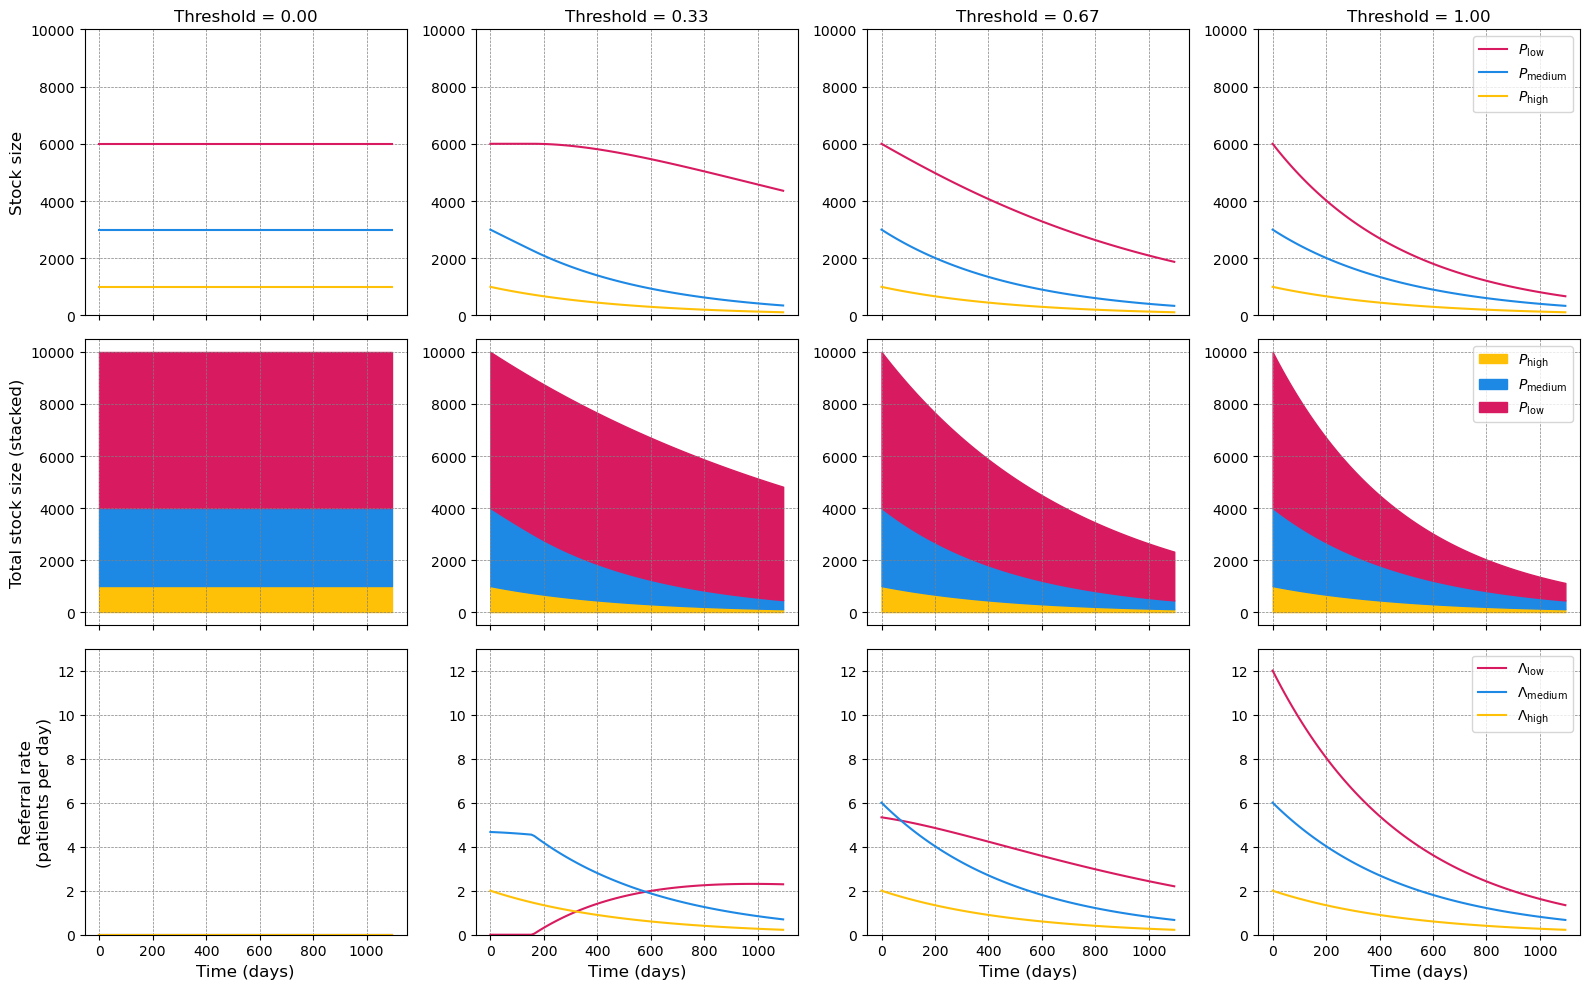

In [19]:
strict_priority_thresholds = [0.0, 1 / 3, 2 / 3, 1.0]

strict_priority_results = [
    run_sd_model(
        time_points=PLOT_TIME_POINTS,
        gatekeeping_function=gk.strict_priority_gatekeeping(
            threshold=threshold,
        ),
        deterioration_function=zero_deterioration_rate_function,
    )
    for threshold in strict_priority_thresholds
]

plot_three_row_comparison(
    strict_priority_results,
    [
        f"Threshold = {threshold:.2f}"
        for threshold in strict_priority_thresholds
    ],
    PLOT_TIME_POINTS,
    referral_ylim=(0, 13),
    output_filename="strict_priority_threshold_comparison.pdf",
)

## Presenting Behaviour

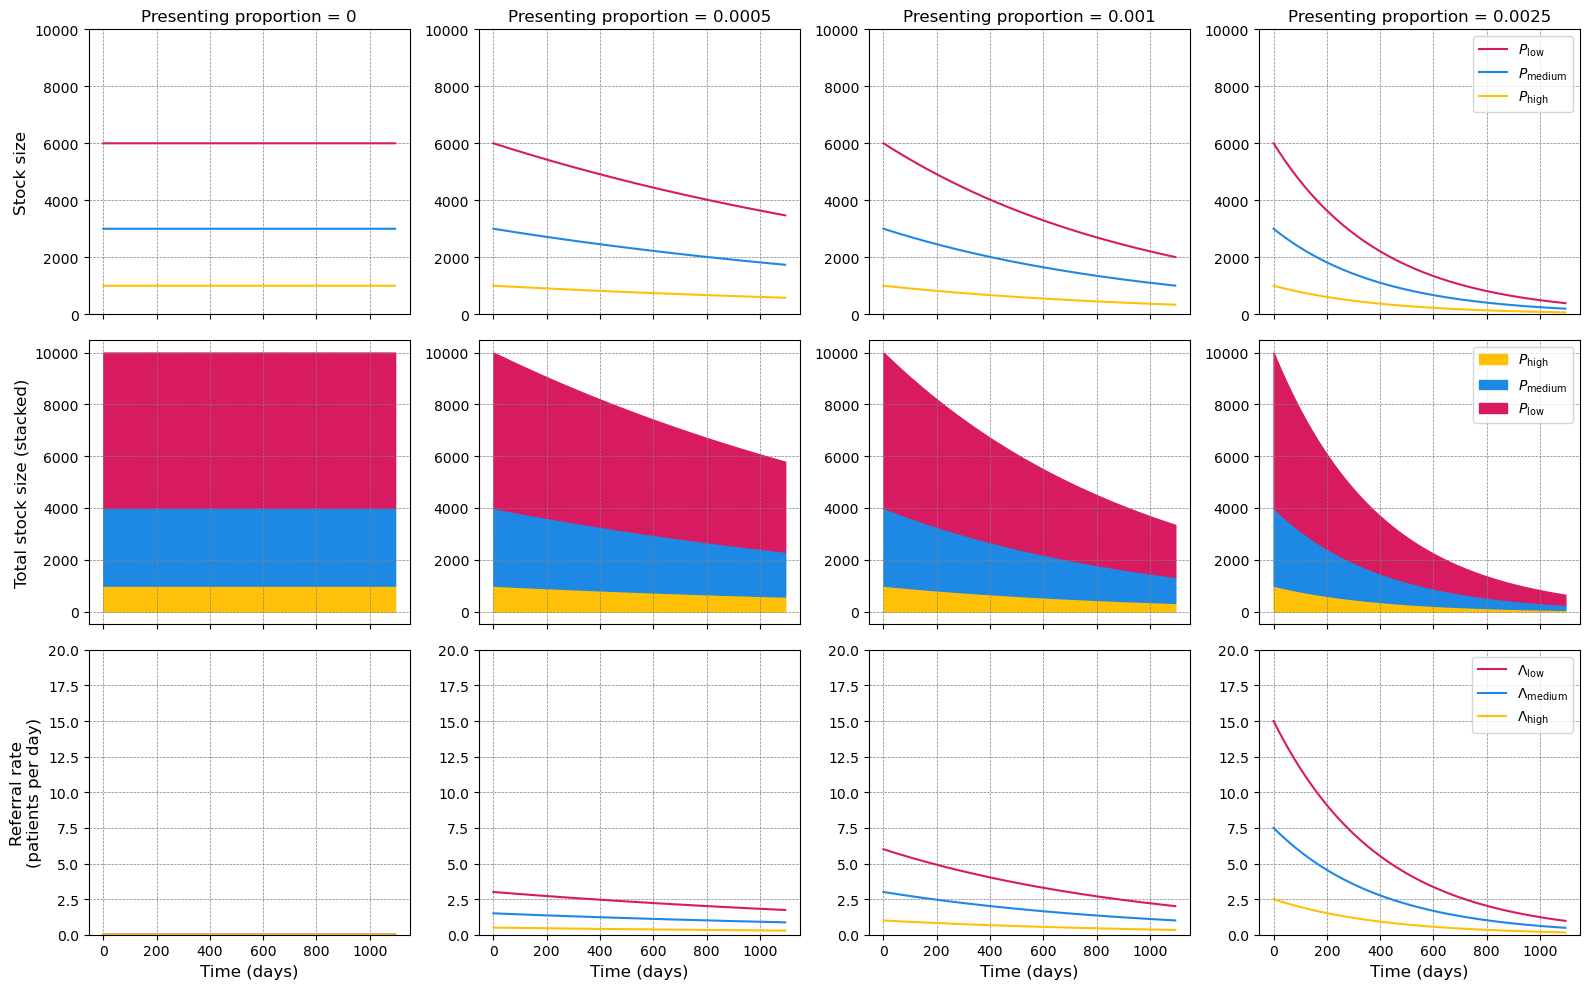

In [20]:
presenting_proportions = [0.0, 0.0005, 0.001, 0.0025]

presenting_results = [
    run_sd_model(
        time_points=FINE_TIME_POINTS,
        gatekeeping_function=gk.strict_priority_gatekeeping(
            threshold=1.0,
        ),
        presenting_proportion=presenting_proportion,
        deterioration_function=zero_deterioration_rate_function,
    )
    for presenting_proportion in presenting_proportions
]

plot_three_row_comparison(
    presenting_results,
    [
        f"Presenting proportion = {proportion:g}"
        for proportion in presenting_proportions
    ],
    FINE_TIME_POINTS,
    referral_ylim=(0, 20),
    output_filename="strict_priority_presenting_comparison.pdf",
)

## Gatekeeping Function Verification

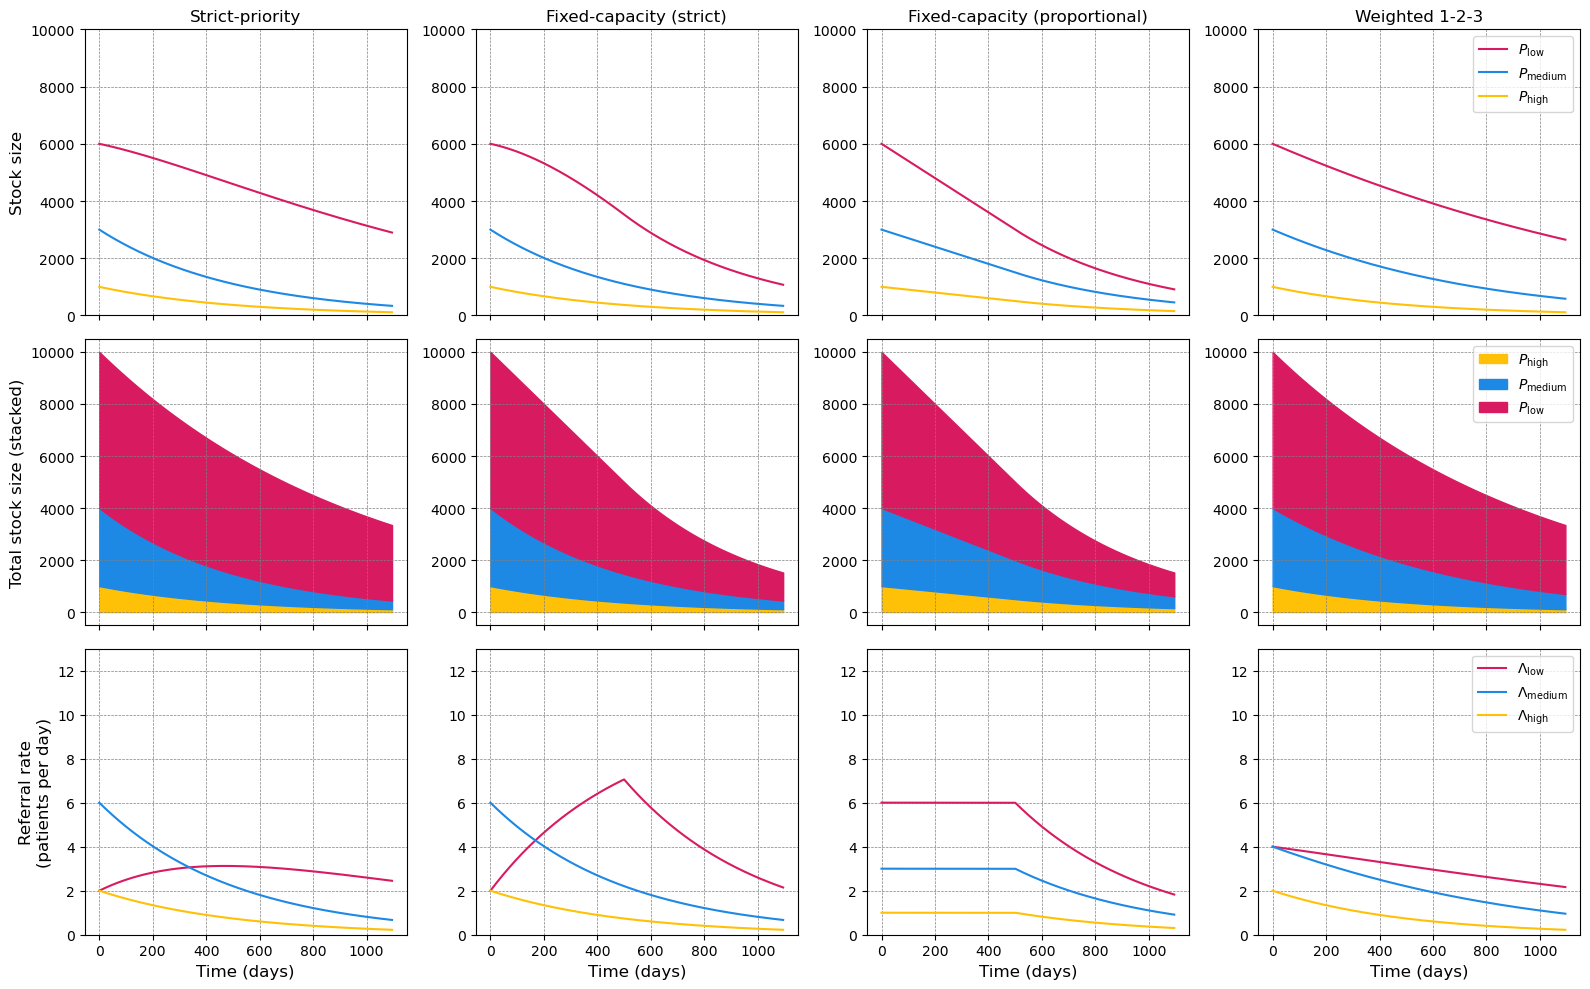

In [22]:
policy_specs = [
    (
        "Strict-priority",
        gk.strict_priority_gatekeeping(threshold=0.5),
    ),
    (
        "Fixed-capacity (strict)",
        gk.fixed_capacity_strict_gatekeeping(capacity=10),
    ),
    (
        "Fixed-capacity (proportional)",
        gk.fixed_capacity_proportional_gatekeeping(capacity=10),
    ),
    (
        "Weighted 1-2-3",
        gk.weighted_priority_gatekeeping(
            threshold=0.5,
            weights=[1, 2, 3],
        ),
    ),
]

policy_results = [
    run_sd_model(
        time_points=FINE_TIME_POINTS,
        gatekeeping_function=policy,
        deterioration_function=zero_deterioration_rate_function,
    )
    for _, policy in policy_specs
]

plot_three_row_comparison(
    policy_results,
    [name for name, _ in policy_specs],
    FINE_TIME_POINTS,
    referral_ylim=(0, 13),
    output_filename="gatekeeping_policy_comparison.pdf",
)

## Deterioration Function Behaviour

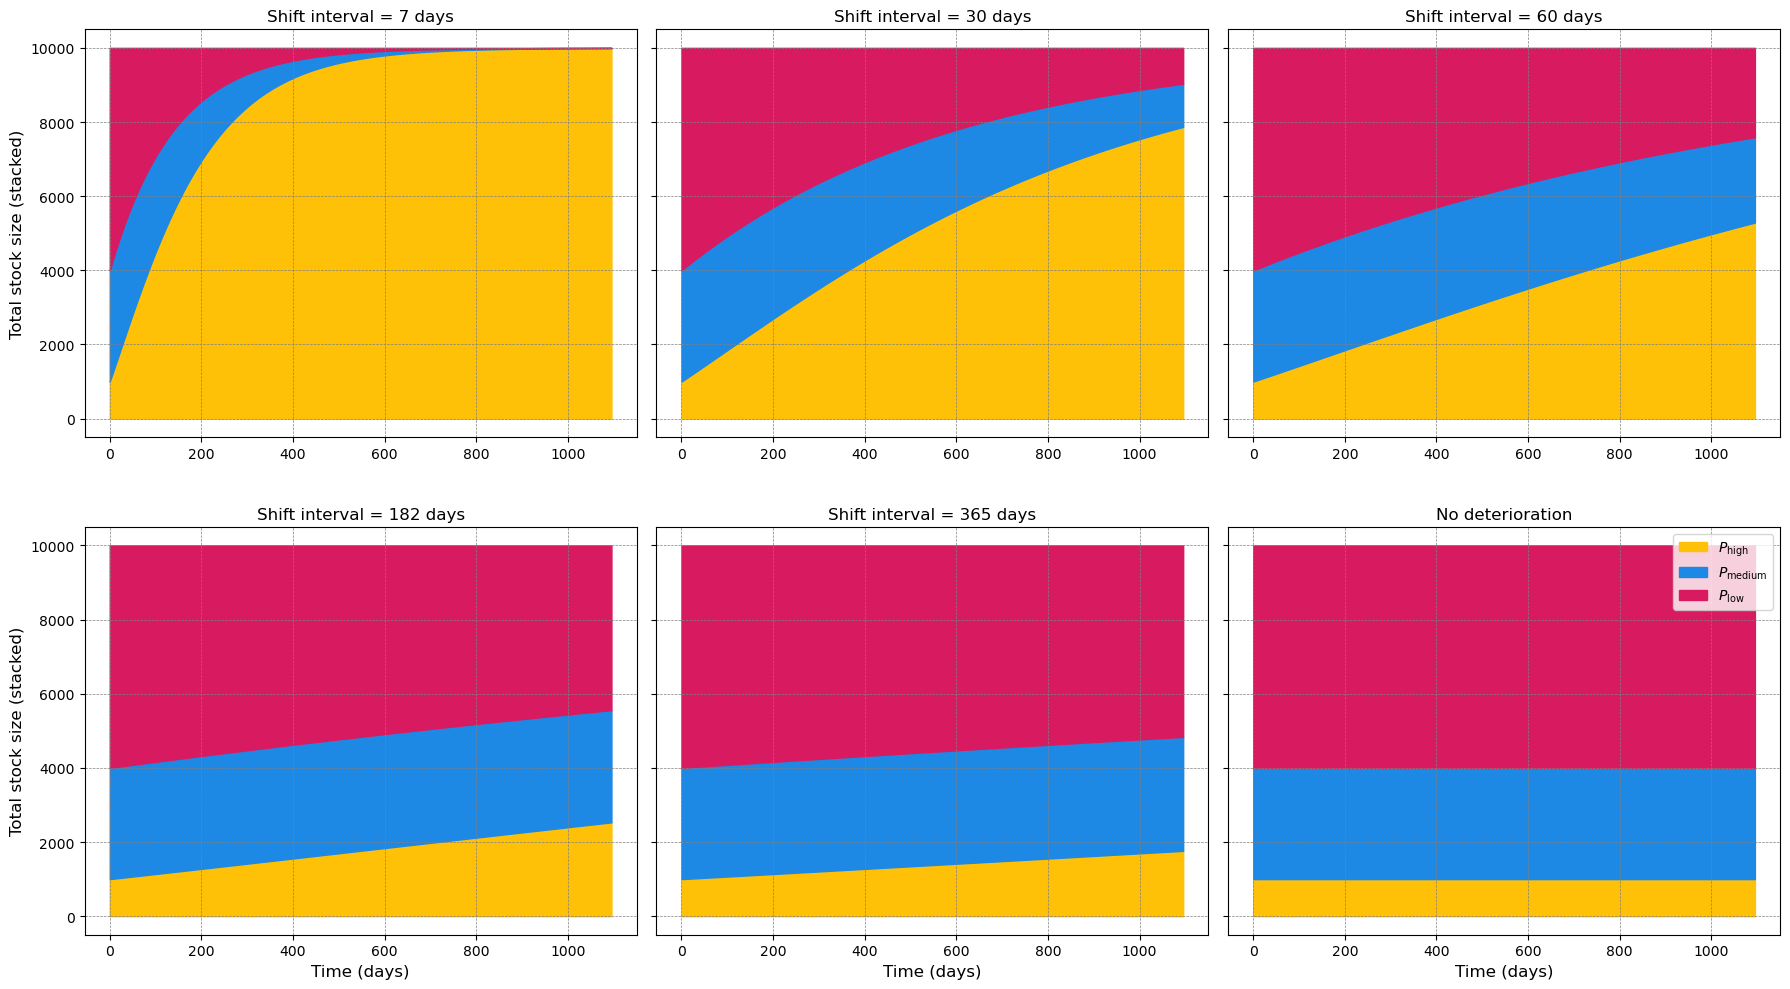

In [23]:
deterioration_specs = [
    ("Shift interval = 7 days", 7, 0.025),
    ("Shift interval = 30 days", 30, 0.025),
    ("Shift interval = 60 days", 60, 0.025),
    ("Shift interval = 182 days", 182, 0.025),
    ("Shift interval = 365 days", 365, 0.025),
    ("No deterioration", 182.5, 0.0),
]

deterioration_results = [
    run_sd_model(
        time_points=FINE_TIME_POINTS,
        gatekeeping_function=gk.strict_priority_gatekeeping(
            threshold=0.0,
        ),
        presenting_proportion=0.0,
        deterioration_function=sd.get_deterioration_rates(
            category_widths=(0.5, 0.3, 0.2),
            shift_proportion=shift_proportion,
            shift_interval_days=shift_interval,
        ),
        incidence_rate=0.0,
        recovery_rate=0.0,
    )
    for _, shift_interval, shift_proportion in deterioration_specs
]

plot_stacked_scenario_grid(
    deterioration_results,
    [title for title, _, _ in deterioration_specs],
    FINE_TIME_POINTS,
    output_filename="deterioration_step_size_stacked_stocks.pdf",
)

## Population Split Behaviour

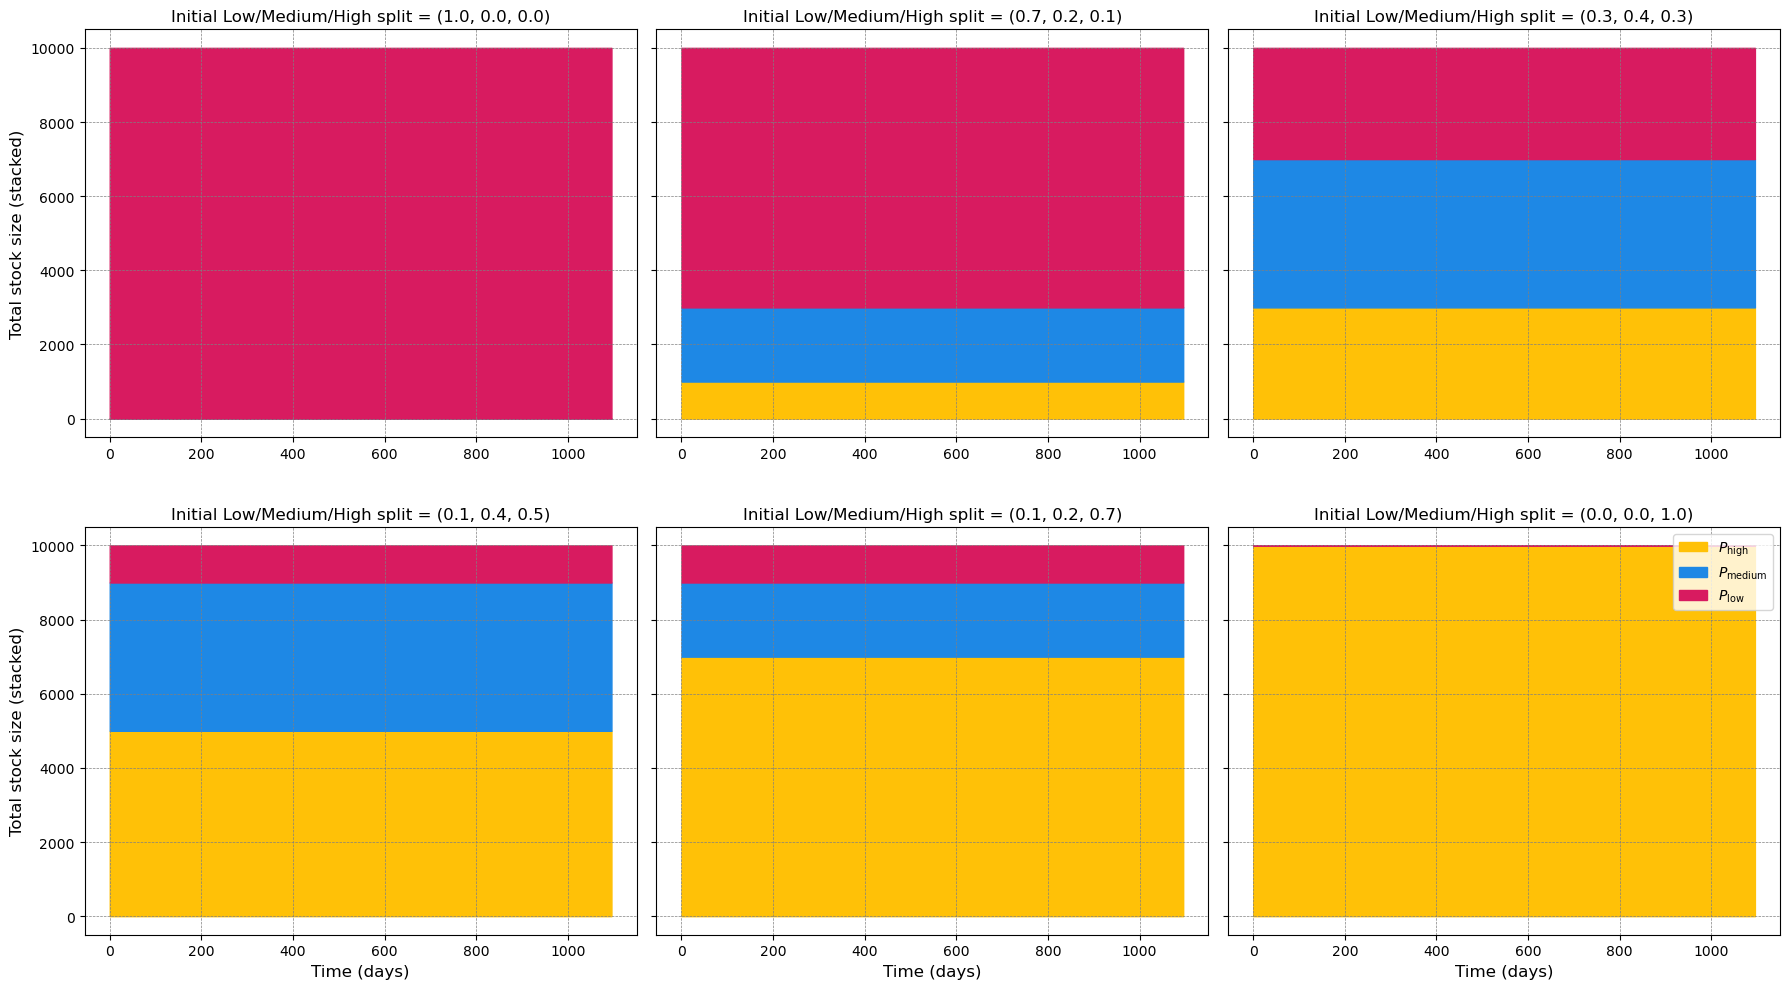

In [25]:
population_splits = [
    (1.0, 0.0, 0.0),
    (0.7, 0.2, 0.1),
    (0.3, 0.4, 0.3),
    (0.1, 0.4, 0.5),
    (0.1, 0.2, 0.7),
    (0.0, 0.0, 1.0),
]

population_split_results = [
    run_sd_model(
        time_points=FINE_TIME_POINTS,
        gatekeeping_function=gk.strict_priority_gatekeeping(
            threshold=0.0,
        ),
        unwell_splits=split,
        deterioration_function=zero_deterioration_rate_function,
    )
    for split in population_splits
]

plot_stacked_scenario_grid(
    population_split_results,
    [
        f"Initial Low/Medium/High split = {split}"
        for split in population_splits
    ],
    FINE_TIME_POINTS,
    output_filename="unwell_proportions_stacked_stocks.pdf",
)

## Incidence Behaviour

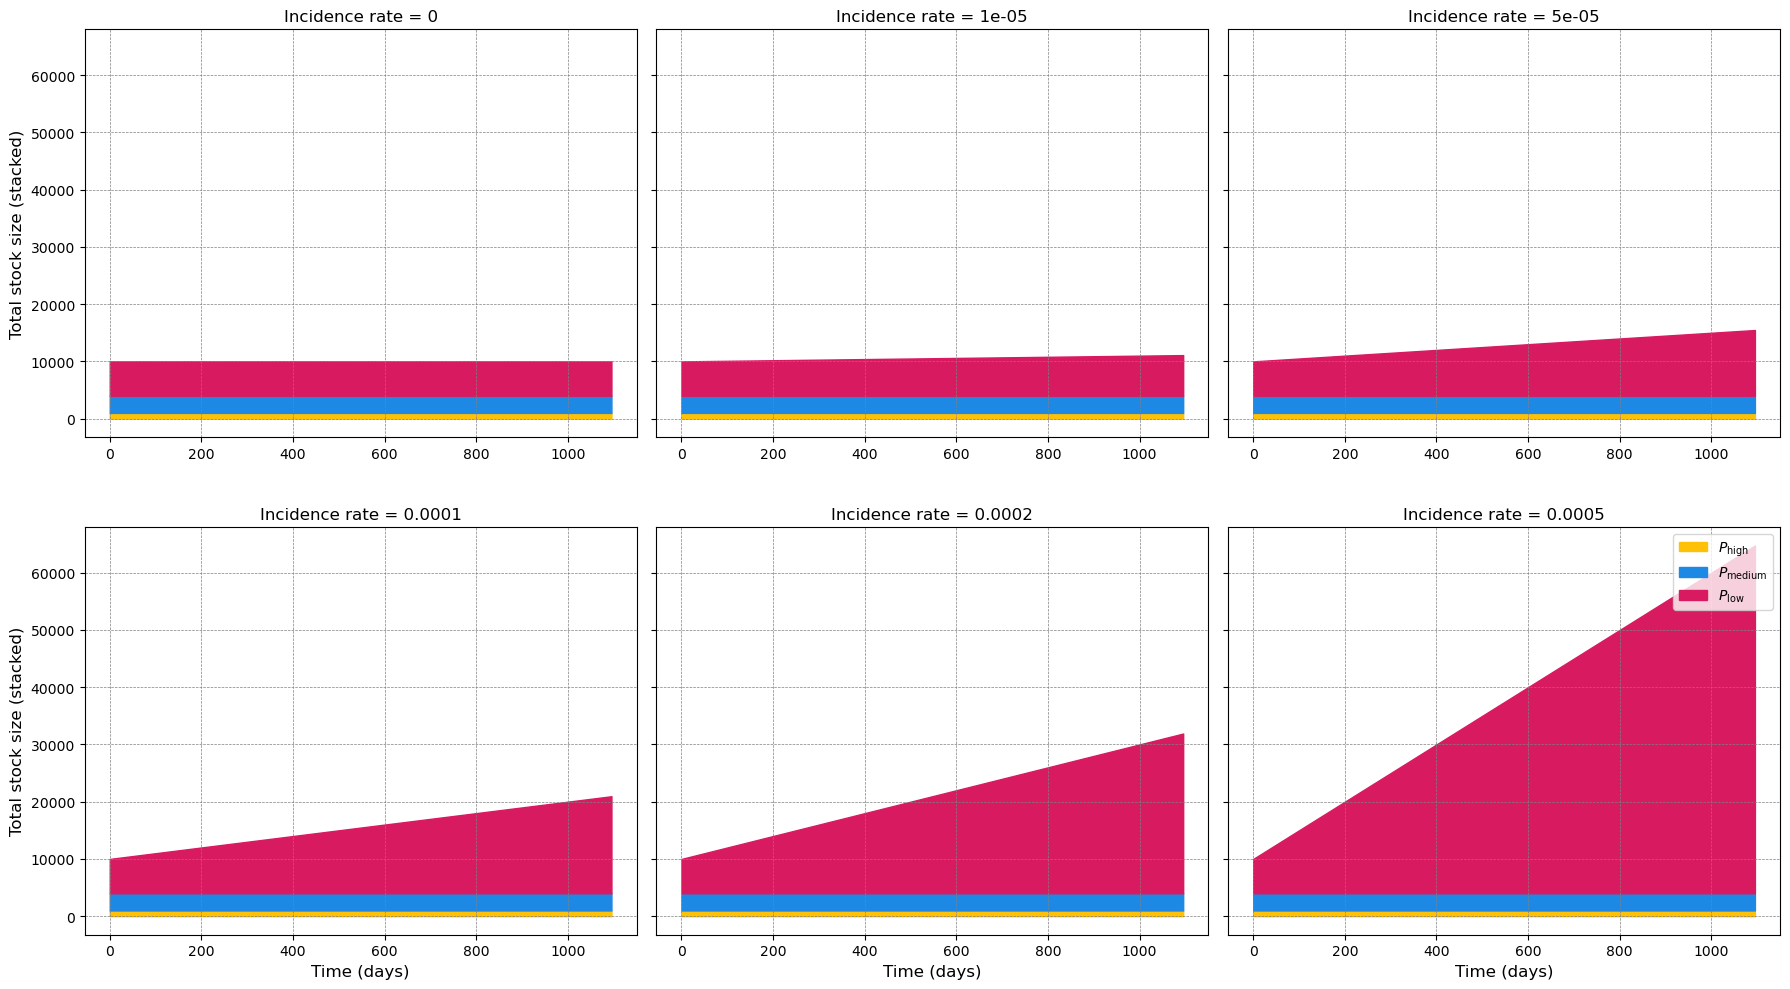

In [26]:
incidence_rates = [0, 0.00001, 0.00005, 0.0001, 0.0002, 0.0005]

incidence_results = [
    run_sd_model(
        time_points=FINE_TIME_POINTS,
        gatekeeping_function=gk.strict_priority_gatekeeping(
            threshold=0.0,
        ),
        presenting_proportion=0.0,
        deterioration_function=zero_deterioration_rate_function,
        incidence_rate=incidence_rate,
        recovery_rate=0.0,
    )
    for incidence_rate in incidence_rates
]

plot_stacked_scenario_grid(
    incidence_results,
    [
        f"Incidence rate = {incidence_rate:g}"
        for incidence_rate in incidence_rates
    ],
    FINE_TIME_POINTS,
    output_filename="incidence_rates_stacked_stocks.pdf",
)

## Recovery Function Behaviour

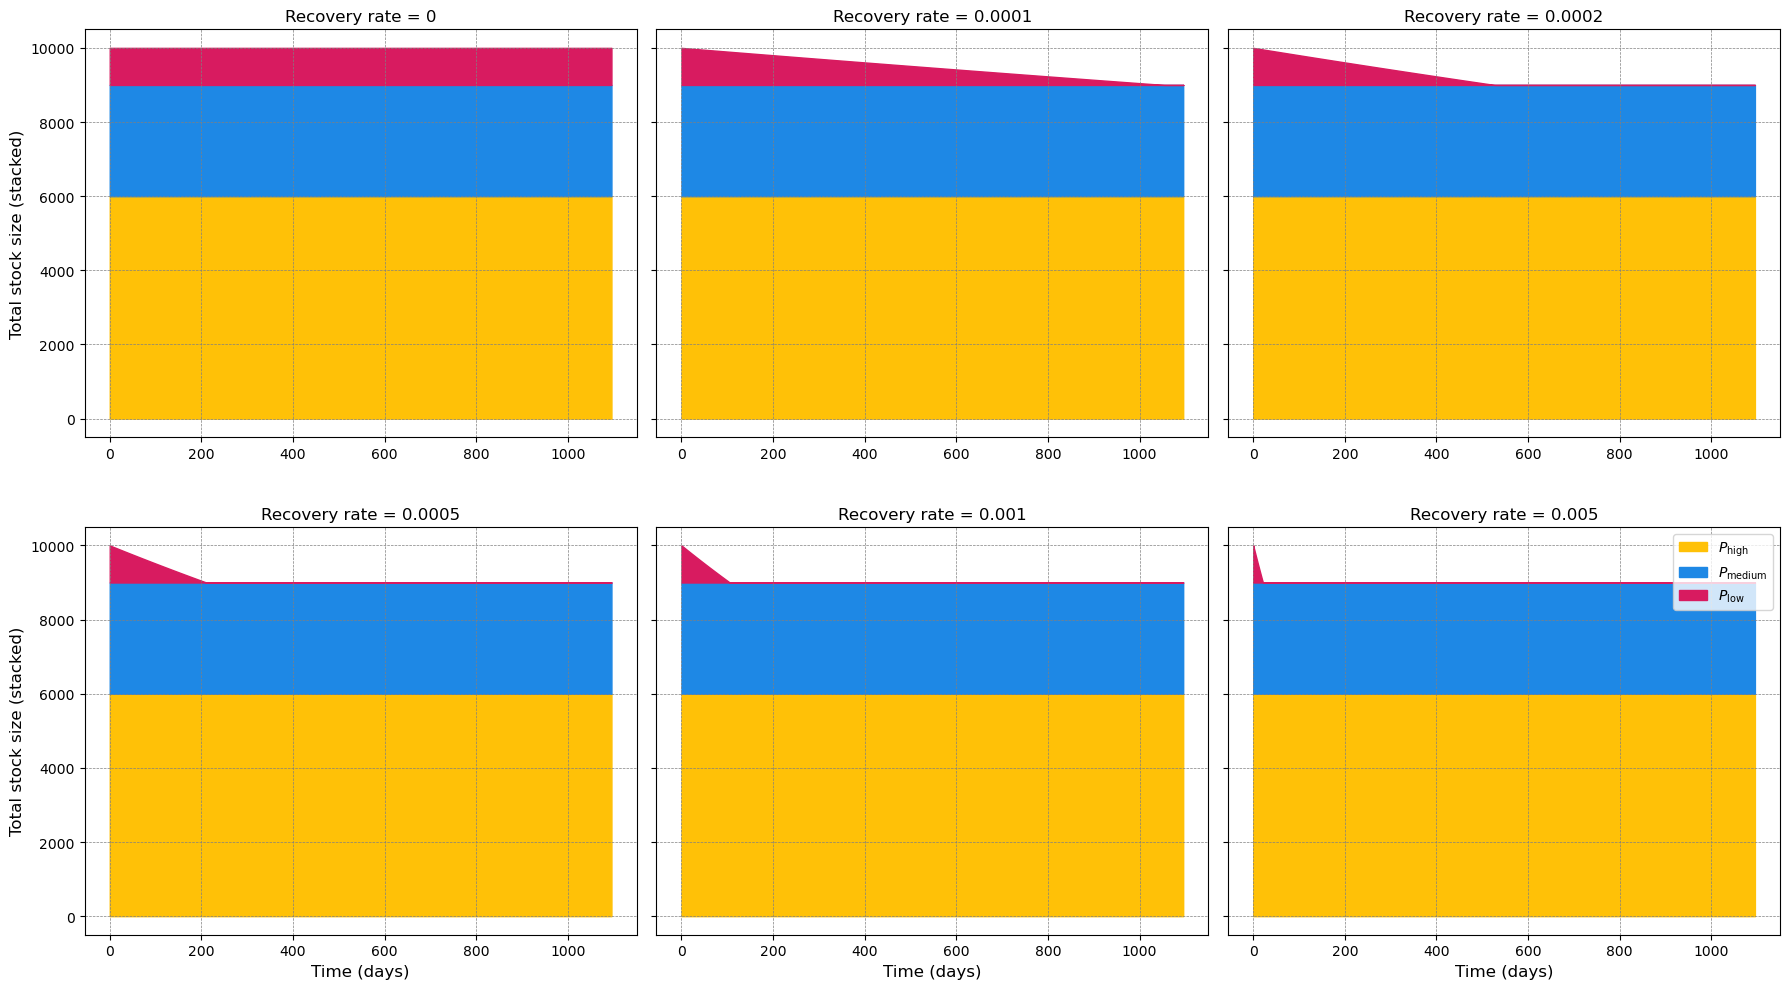

In [27]:
recovery_rates = [0, 0.0001, 0.0002, 0.0005, 0.001, 0.005]

recovery_results = [
    run_sd_model(
        time_points=FINE_TIME_POINTS,
        gatekeeping_function=gk.strict_priority_gatekeeping(
            threshold=0.0,
        ),
        unwell_splits=(0.1, 0.3, 0.6),
        presenting_proportion=0.0,
        deterioration_function=zero_deterioration_rate_function,
        incidence_rate=0.0,
        recovery_rate=recovery_rate,
    )
    for recovery_rate in recovery_rates
]

plot_stacked_scenario_grid(
    recovery_results,
    [
        f"Recovery rate = {recovery_rate:g}"
        for recovery_rate in recovery_rates
    ],
    FINE_TIME_POINTS,
    output_filename="recovery_rates_stacked_stocks.pdf",
)

## Deterioration x Strict-Priority Referrals Behaviour

In [28]:
combined_thresholds = [0.0, 0.25, 0.5, 1.0]

combined_deterioration_specs = [
    ("Shift interval = 7 days", 7, 0.025),
    ("Shift interval = 60 days", 60, 0.025),
    ("Shift interval = 182 days", 182, 0.025),
    ("No deterioration", 182.5, 0.0),
]

combined_results = {
    (row_label, threshold): run_sd_model(
        time_points=FINE_TIME_POINTS,
        gatekeeping_function=gk.strict_priority_gatekeeping(
            threshold=threshold,
        ),
        deterioration_function=sd.get_deterioration_rates(
            category_widths=(0.5, 0.3, 0.2),
            shift_proportion=shift_proportion,
            shift_interval_days=shift_interval,
        ),
        recovery_rate=0.0,
    )
    for row_label, shift_interval, shift_proportion
    in combined_deterioration_specs
    for threshold in combined_thresholds
}

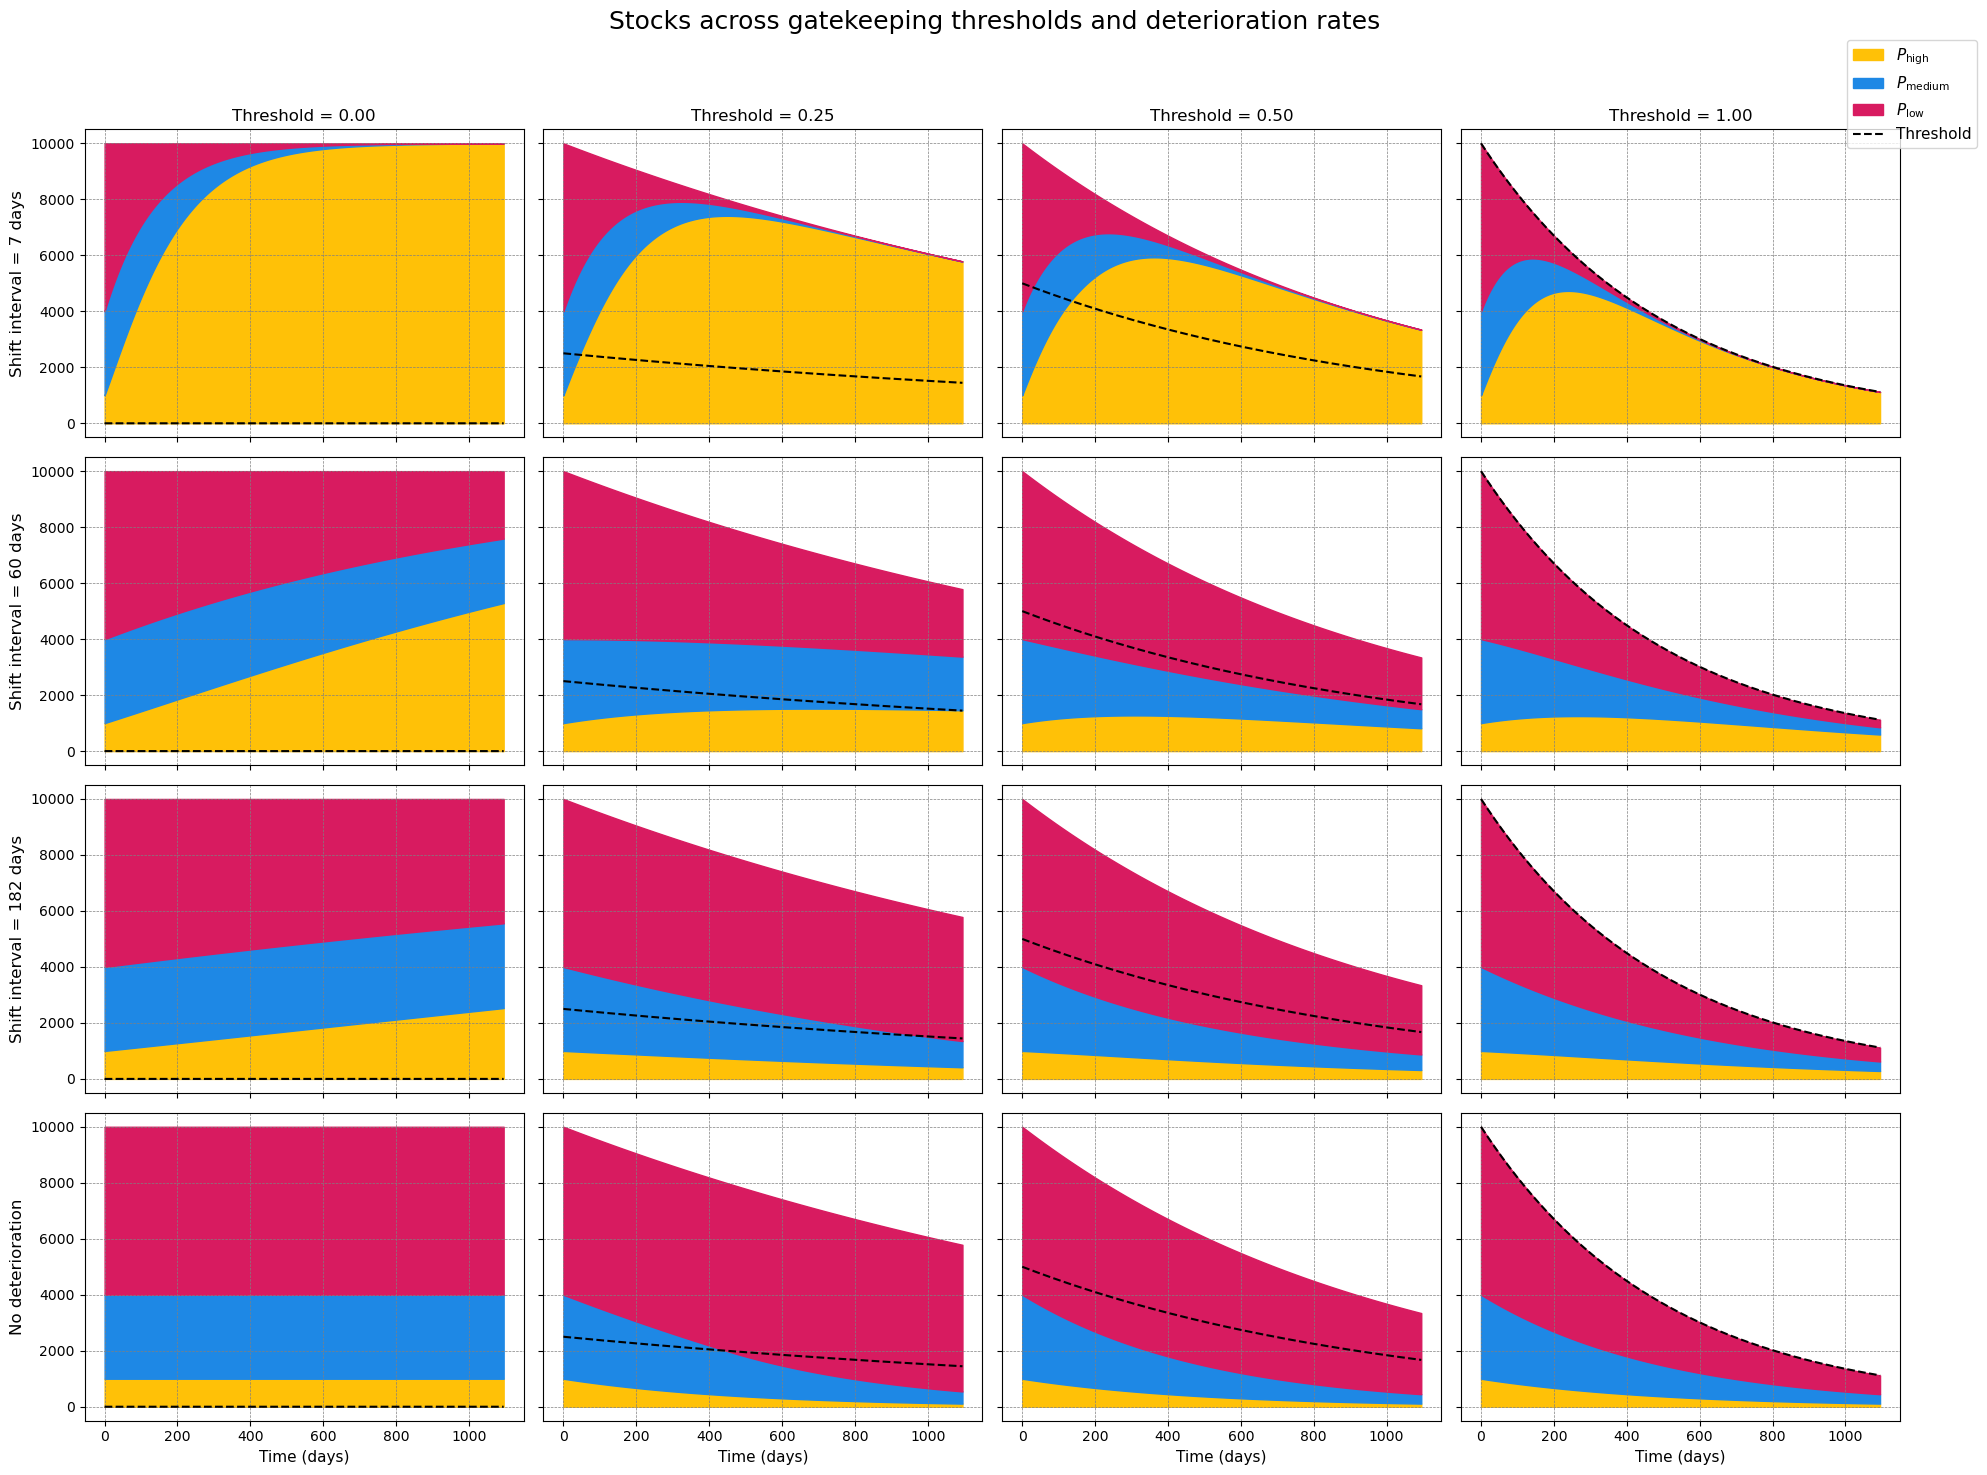

In [29]:
fig, axes = plt.subplots(
    len(combined_deterioration_specs),
    len(combined_thresholds),
    figsize=(20, 15),
    sharex=True,
    sharey=True,
    squeeze=False,
)

fig.suptitle(
    "Stocks across gatekeeping thresholds and deterioration rates",
    fontsize=18,
)

for row_index, (row_label, _, _) in enumerate(
    combined_deterioration_specs
):
    for column_index, threshold in enumerate(combined_thresholds):
        ax = axes[row_index, column_index]
        result = combined_results[(row_label, threshold)]

        plot_stacked_stocks_over_time_ax(
            ax,
            result["stocks"],
            FINE_TIME_POINTS,
            threshold=threshold,
        )

        if row_index == 0:
            ax.set_title(
                f"Threshold = {threshold:.2f}",
                fontsize=12,
            )

        if column_index == 0:
            ax.set_ylabel(row_label, fontsize=12)

        if row_index == len(combined_deterioration_specs) - 1:
            ax.set_xlabel("Time (days)", fontsize=11)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper right",
    bbox_to_anchor=(0.995, 0.965),
    fontsize=11,
)

fig.tight_layout(rect=[0, 0, 0.96, 0.95])

fig.savefig(
    PLOT_DIR / "gatekeeping_threshold_deterioration_comparison.pdf",
    dpi=300,
    bbox_inches="tight",
)
plt.show()